<a href="https://colab.research.google.com/github/RonakkudalAI/AI-ML-PRIME-BATCH/blob/main/Heart(day11).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

In [88]:
dataset = pd.read_csv("/content/heart (1).csv")
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [89]:
dataset.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [90]:
dataset.duplicated().sum()

np.int64(1)

In [91]:
dataset.drop_duplicates(inplace=True)

In [92]:
dataset.duplicated().sum()

np.int64(0)

In [93]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [94]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


<Axes: >

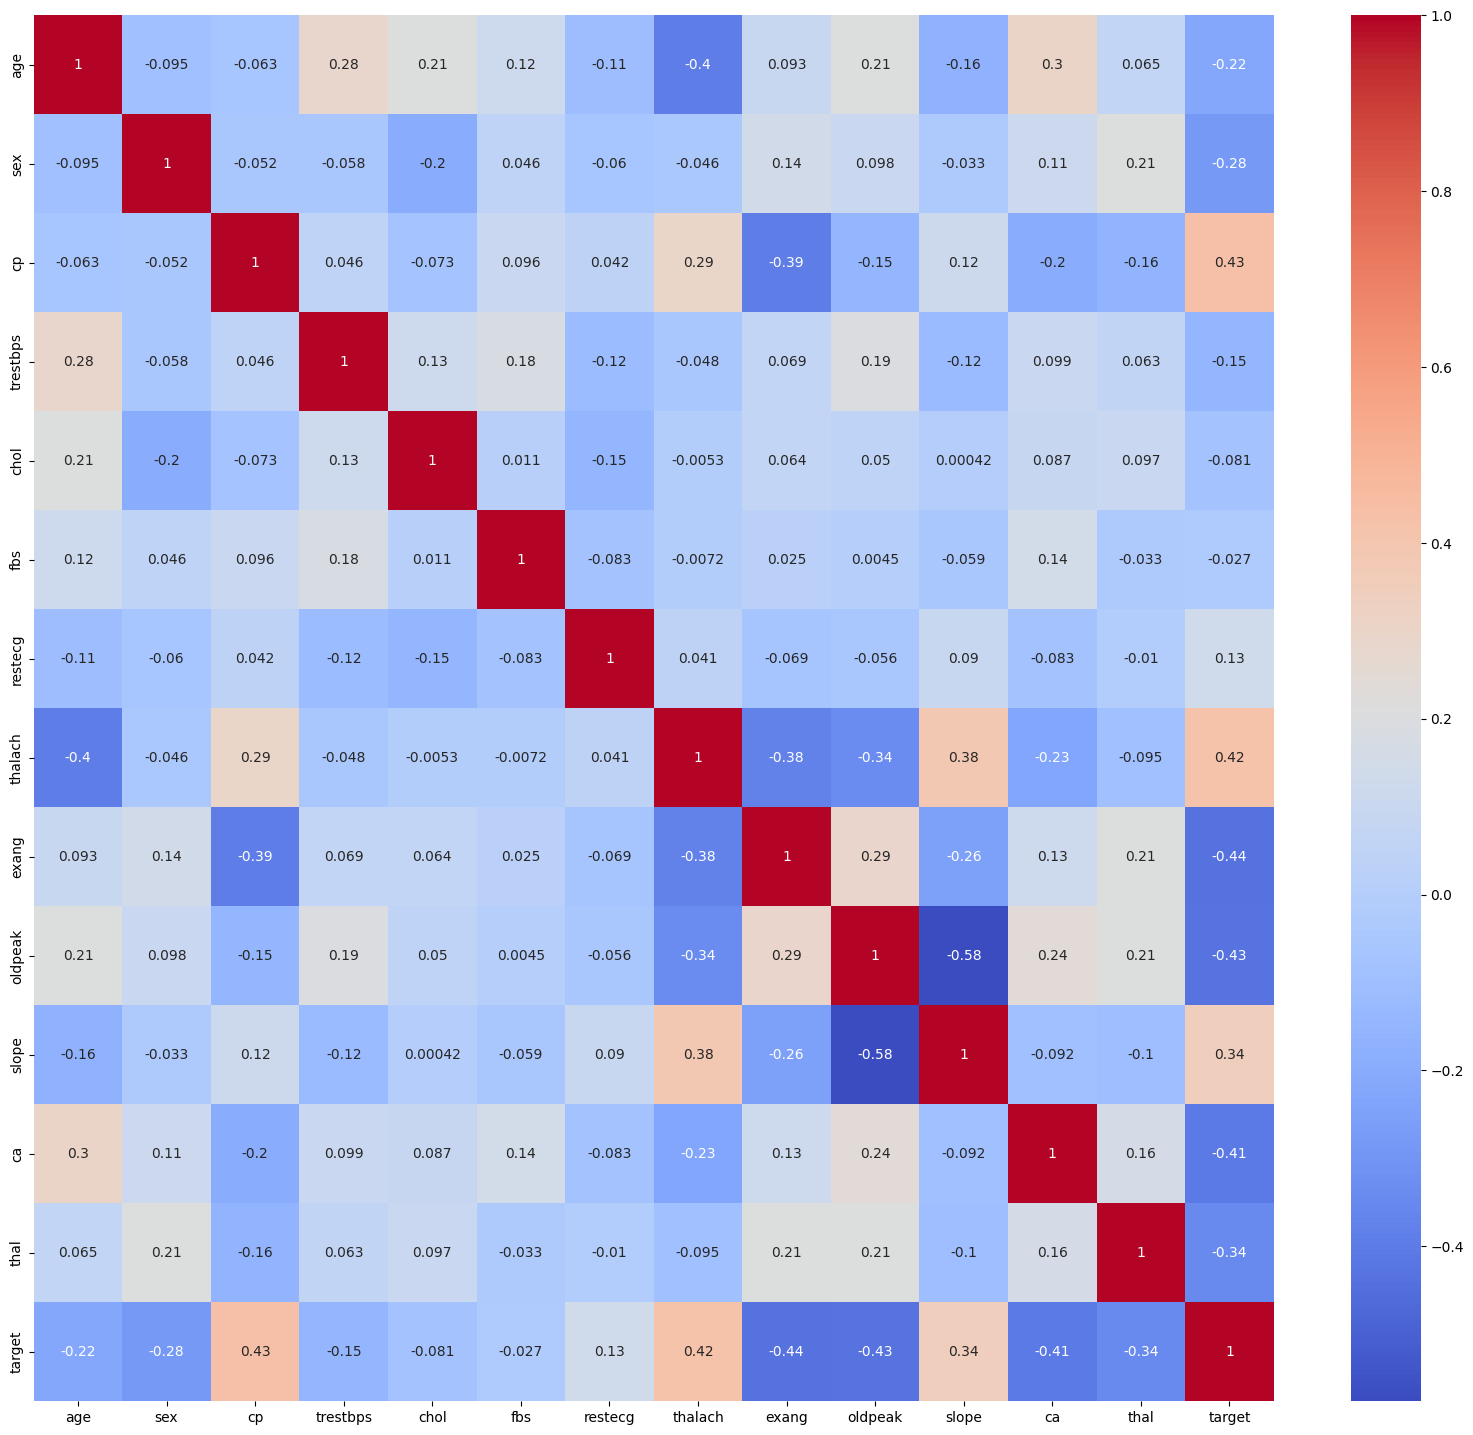

In [95]:
plt.figure(figsize=(20,18))
sns.heatmap(dataset.corr(),annot=True,cmap='coolwarm')

<Axes: xlabel='age', ylabel='Count'>

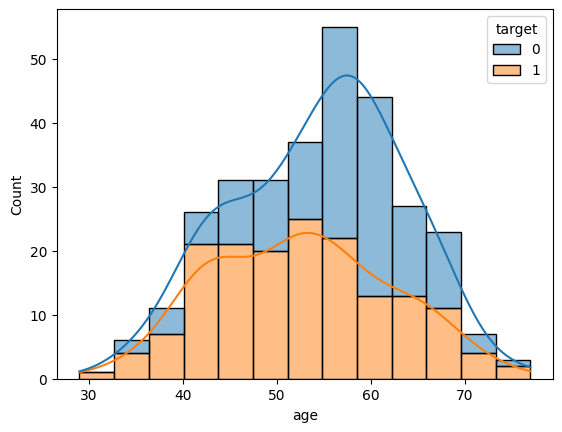

In [96]:
sns.histplot(data = dataset, x='age', hue='target', multiple='stack', kde=True)

<Axes: xlabel='target', ylabel='count'>

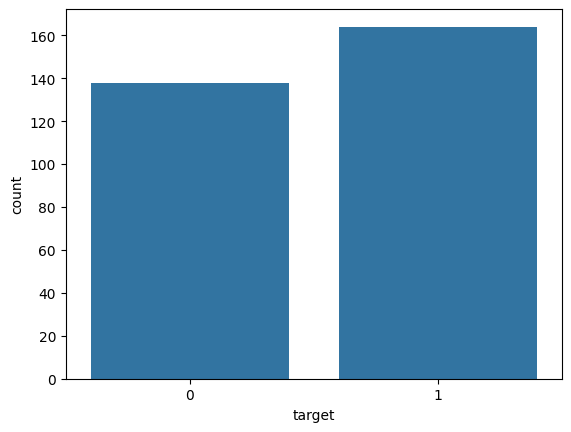

In [97]:
sns.countplot(x='target', data = dataset)

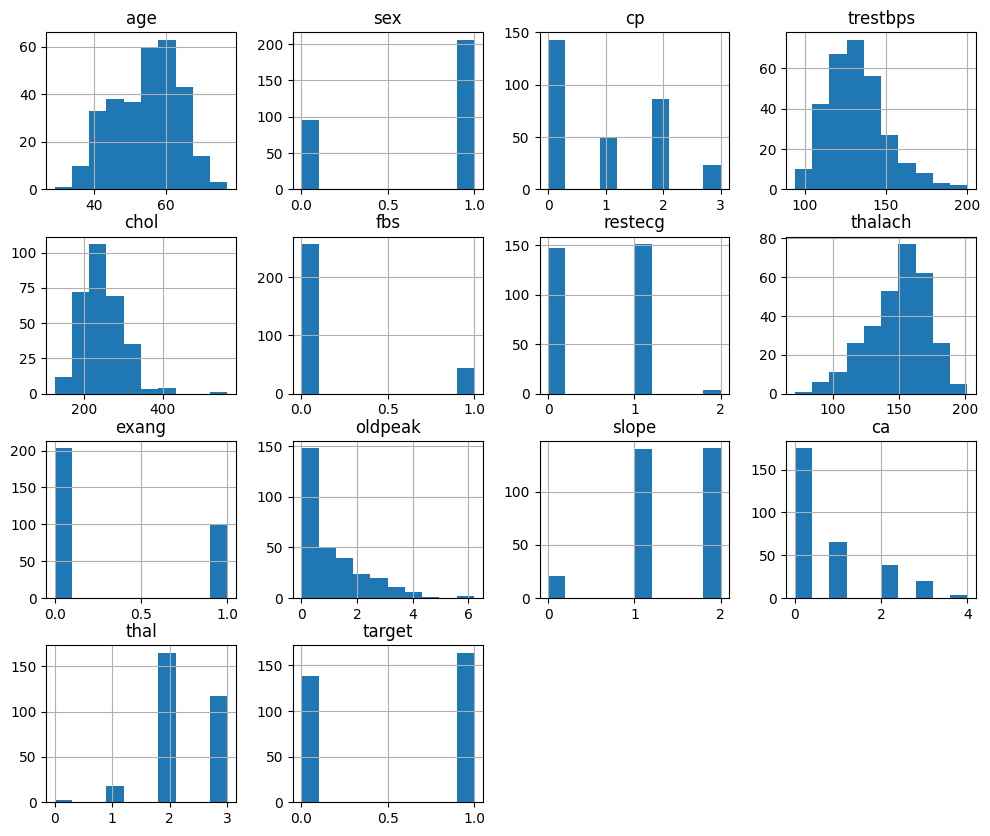

In [98]:
dataset.hist(figsize=(12,10))
plt.show()

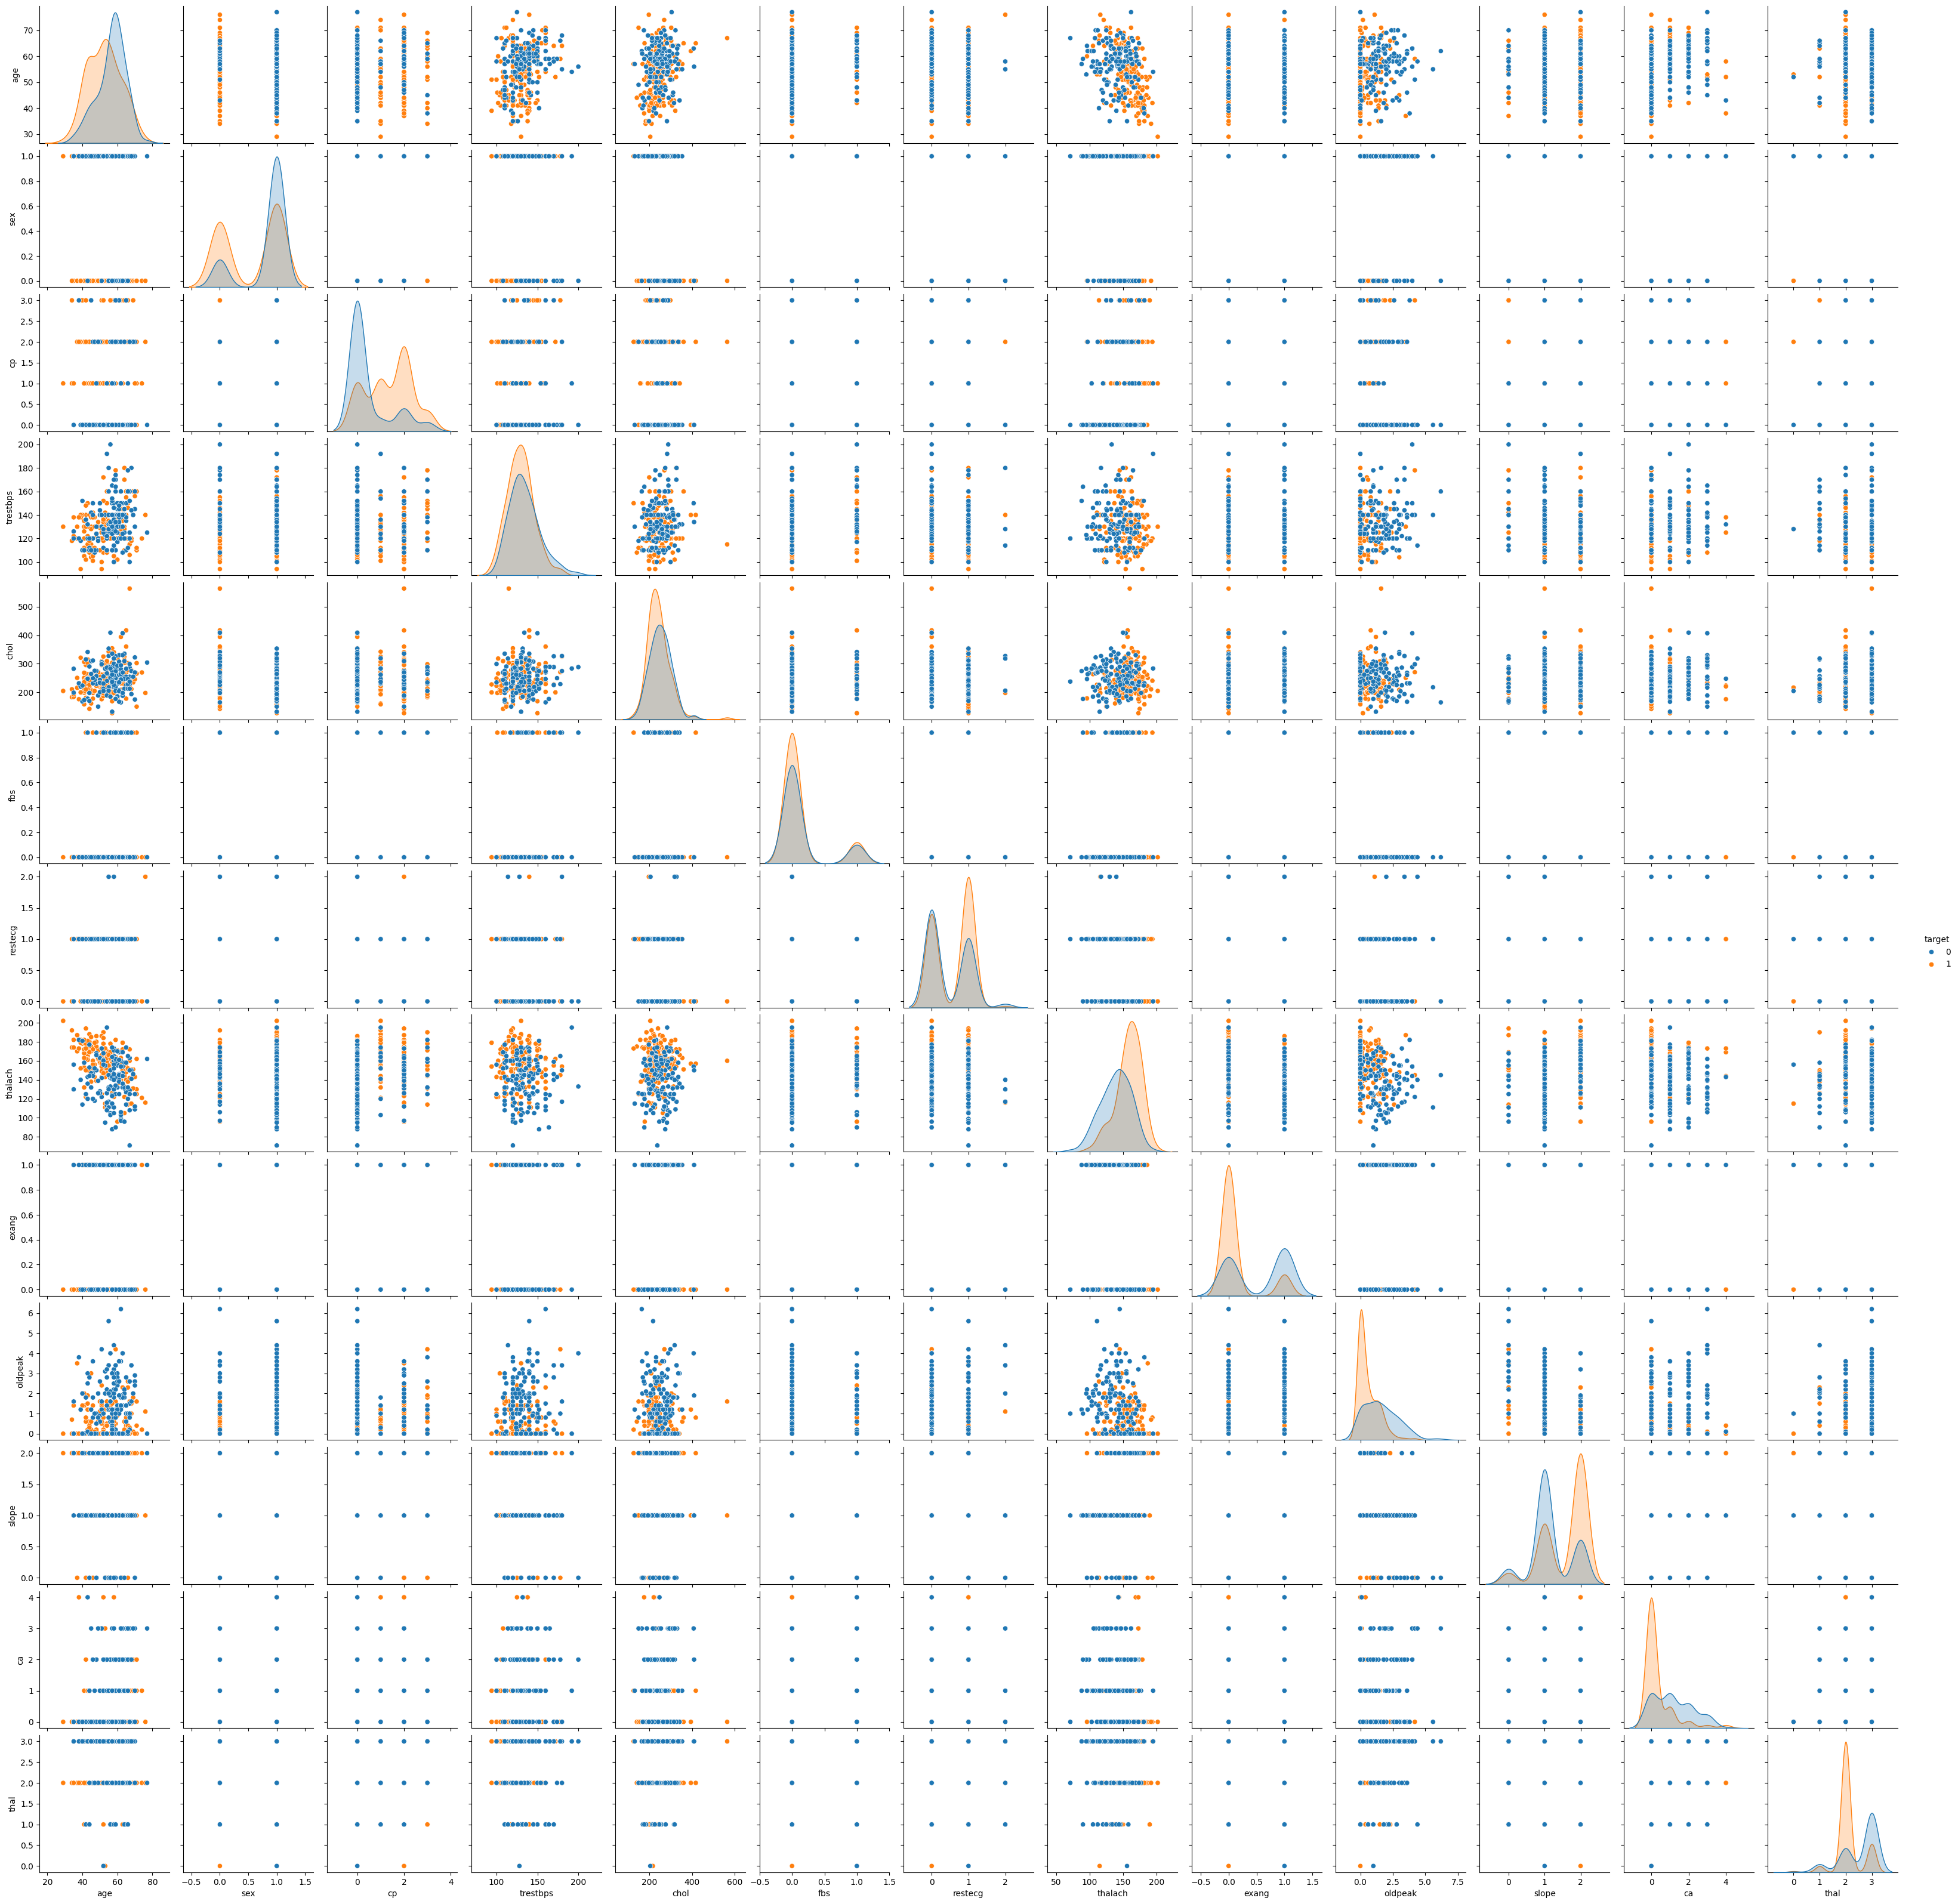

In [99]:
sns.pairplot(hue='target', data = dataset)

In [100]:
dataset['age_calestrol'] = dataset['age'] * dataset['chol']
dataset['age_bloodpressure'] = dataset['age'] * dataset['trestbps']

In [101]:
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_calestrol,age_bloodpressure
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,14679,9135
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,9250,4810
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,8364,5330
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,13216,6720
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,20178,6840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0,13737,7980
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0,11880,4950
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0,13124,9792
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0,7467,7410


In [102]:
dataset.shape


(302, 16)

In [103]:
X = dataset.drop('target', axis=1)
y = dataset['target']

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
from sklearn.preprocessing import StandardScaler
Sc = StandardScaler()
X_train_scaled = Sc.fit_transform(X_train)
X_test_scaled = Sc.transform(X_test)

In [110]:
from sklearn.svm import SVC

model = SVC(kernel='linear', random_state=0)

model.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=0)

In [111]:
y_pred = model.predict(X_test_scaled)

In [113]:
print("Accuracy Score ",accuracy_score(y_test,y_pred))
print("Confusion matrix",confusion_matrix(y_test,y_pred))

Accuracy Score  0.819672131147541
Confusion matrix [[24  5]
 [ 6 26]]


In [114]:
from sklearn.svm import SVC

rbf_model = SVC(kernel='rbf', random_state=0)

rbf_model.fit(X_train_scaled, y_train)

SVC(random_state=0)

In [115]:
y_pred_rbf = rbf_model.predict(X_test_scaled)

In [116]:
print("Accuracy Score ",accuracy_score(y_test,y_pred_rbf))
print("Confusion matrix",confusion_matrix(y_test,y_pred_rbf))

Accuracy Score  0.8688524590163934
Confusion matrix [[26  3]
 [ 5 27]]


HyperTunning using Grid

In [117]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C' : [0.1,1,10,100],
    'gamma' :['scale',0.1, 0.01],
    'kerner':['rbf']
}

In [118]:
grid = GridSearchCV(estimator=SVC(),param_grid =param_grid, scoring='accuracy',cv=10,n_jobs=-1)



In [121]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C' : [0.1,1,10,100],
    'gamma' :['scale',0.1, 0.01],
    'kernel':['rbf'] # Corrected 'kerner' to 'kernel'
}

grid = GridSearchCV(estimator=SVC(),param_grid =param_grid, scoring='accuracy',cv=10,n_jobs=-1)
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=10, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.1, 0.01],
                         'kernel': ['rbf']},
             scoring='accuracy')

In [122]:
grid.best_score_

np.float64(0.8341666666666665)

In [124]:
grid.best_score_

np.float64(0.8341666666666665)